In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import ipywidgets as widgets 
from ipywidgets import interact, Dropdown, IntSlider
from scipy.io import loadmat
from scipy.spatial import Delaunay
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os

### Load the Look Up Table

In [3]:
lut = loadmat('lookup_table.mat')
params = lut['params']     
#If some parameters are not varying, they must be removed from the table to allow the interpolation : here kappa = 0.01
dim_to_remove = 4
params = np.delete(params, dim_to_remove, axis=1)
signals = lut['signals_4D']            
sequence = lut['sequence']

### Delaunay interpolation

In [4]:
def interpolate_signal(f, Dex, rmean, rsd, bval, TD, delta, bvecs, tri):
    if f<0.007:  #less than 10 cells in the voxel
            return 1 #put the value for tumor-empty voxels

    query_params = np.array([f, Dex, rmean, rsd]) 
                
    #Extract b values, diffusion time, directions of gradient
    n_bval = int(sequence['n_bval'][0][0][0][0])
    n_bvec = int(sequence['n_bvec'][0][0][0][0])
    n_TD = int(sequence['n_del'][0][0][0][0])
                
    bvals = sequence['bval'][0][0]   # shape: (n_bval,)
    TDs = sequence['TD'][0][0] # shape: (n_del,)
    bvecs = [int(i) for i in bvecs]
    TD_index = np.where(TDs == TD)[0][0]
    if TD_index.size == 0:
            raise ValueError(f"TD = {TD} not found in the LUT.")
    bval_index = np.where(bvals == bval)[0][0]
    if bval_index.size == 0:
            raise ValueError(f"bval = {bval} not found in the LUT.")

    #Find the simplex containing the point of interest
    simplex_index = tri.find_simplex(query_params)

    if simplex_index == -1:
            print(f"The point {query_params} is out of the convex hull for triangulation.")
            print('Minimum of the hull is ', np.min(params, axis=0), ' and maximum is ', np.max(params, axis=0))

            # Remove Dex
            params_3D = np.delete(params, 1, axis=1)
            query_3D = np.delete(query_params, 1)

            # Convex hull and visualization
            hull = ConvexHull(params_3D)
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')

            # LUT points
            ax.scatter(params_3D[:, 0], params_3D[:, 1], params_3D[:, 2], alpha=0.3, label='LUT points')

            # Query point
            ax.scatter(query_3D[0], query_3D[1], query_3D[2], c='r', label='Query point', s=50)

            # Surface plot of the convex hull
            faces = [params_3D[simplex] for simplex in hull.simplices]
            poly3d = Poly3DCollection(faces, facecolors='lightblue', linewidths=0.2, edgecolors='k', alpha=0.3)
            ax.add_collection3d(poly3d)

            ax.set_xlabel("f")
            ax.set_ylabel("rmean")
            ax.set_zlabel("rsd")
            ax.legend()
            plt.tight_layout()
            plt.show()

            return np.nan

    else:
            #print('Minimum of the hull is ', np.min(params, axis=0), ' and maximum is ', np.max(params, axis=0))
            # Get the vertices of the simplex
            vertex_index = tri.simplices[simplex_index]  
            #print(vertex_index)

            # Extract the coordinates
            vertices = params[vertex_index]  
            #print(vertices)

            # Extract barycentric coordinates
            T = vertices[1:] - vertices[0]  
            v = query_params - vertices[0]  
            bary_coords = np.linalg.solve(T.T, v)  
            bary_coords = np.append(1 - np.sum(bary_coords), bary_coords) 

            # Security
            if np.any(bary_coords < -1e-6):
                print(f"Negative barycentric coordinates => possible extrapolation")
    
            # Get the signals for each vertex
            signals_subset = signals[vertex_index] 

            # Linear combination of the signals with the weights from the simplex
            interpolated_signal = np.tensordot(bary_coords, signals_subset, axes=(0, 0))  

            # Extraction of the signal for TD, bvalue and mean over the multiple bvecs
            signal_values = interpolated_signal[TD_index, bval_index, :]
            signal_values = signal_values[bvecs]
            signal_avg = np.mean(signal_values)/1e5
            #print(signal_avg)

    return signal_avg

#interpolate_signal(0.6, 2.0, 33, 1, 0.5, 45, 4, (1,2,3))

### (Gaussian, Low) cell density and heterogeneity of extra cellular diffusivity in the tumor 

In [5]:
# AMBER world size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_gaussian_low = np.empty((Nx, Ny, Nz), dtype=object)

# Center coordinates
cx, cy, cz = Nx // 2, Ny // 2, Nz // 2

# Gaussian distribution of cells
sigma = Nx / 15  # width of cell density
f_max = 0.68     # maximum density

# Rest of the parameters
Dex_const = 2.0
rmean_const = 33
rsd_const = 1

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            # Euclidian distance from the center
            d = np.sqrt((i - cx)**2 + (j - cy)**2 + (k - cz)**2)
            
            # Gaussian cellular density
            f = f_max * np.exp(-d**2 / (2 * sigma**2))
            
            # Creation of the dictionary
            AMBER_map_gaussian_low[i, j, k] = {
                "f": f,
                "Dex": Dex_const,
                "rmean": rmean_const,
                "rsd": rsd_const
            }

### (Low, Low) heterogeneity of cell density and extracellular diffusivity in the tumor

In [6]:
# AMBER world size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_low_low = np.empty((Nx, Ny, Nz), dtype=object)

# Center coordinates
cx, cy, cz = Nx // 2, Ny // 2, Nz // 2

# Parameters of the tumor
R_tumor = Nx // 2 - 7     # radius of the tumor
sigma = R_tumor / 1.2     # large standard deviation
f_max = 0.68              # cell density maximal
Dex_center = 2.0          # diffusivity at the center
Dex_edge = 2.2            # sligther higher diffusivity at the edge because of lower cell density ?
rmean_const = 33
rsd_const = 1

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            # Euclidian distance to the center of the tumor
            d = np.sqrt((i - cx)**2 + (j - cy)**2 + (k - cz)**2)
            
            if d > R_tumor:
                # Outside of the tumor there are no cells
                f = 0.0
                Dex = Dex_edge  # Outside Dex
            else:
                # Large gaussian and truncated for low heterogeneity
                f = f_max * np.exp(-d**2 / (2 * sigma**2))
                
                # Linear diffusivity 
                Dex = Dex_center + (Dex_edge - Dex_center) * (d / R_tumor)
            
            AMBER_map_low_low[i, j, k] = {
                "f": f,
                "Dex": Dex,
                "rmean": rmean_const,
                "rsd": rsd_const
            }


### (High, Low) heterogeneity of cell density and extracellular diffusivity in the tumor

In [7]:
# World size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_high_low = np.empty((Nx, Ny, Nz), dtype=object)

# Center of the tumor and other gaussian cell density distributions => gaussian mixture
centers = [
    (Nx // 2, Ny // 2, Nz // 2),  # principal tumor
    (10, 10, 10),                   # subkernel 1
    (14, 14, 14),                 # subkernel 2
]

# Gaussian parameters
gaussians = [
    (Nx / 6, 0.5),  # principal tumor: large gaussian
    (Nx / 20, 0.50),  # subkernel 1, more dense
    (Nx / 18, -0.30),  # subkernel 2, less dense => negative contribution
]

# Other parameters homogeneous
R_tumor = Nx // 2 - 7     # radius of the tumor
Dex_const = 2.0
rmean_const = 33
rsd_const = 1

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            f_total = 0.0
            for (cx, cy, cz), (sigma, f_max) in zip(centers, gaussians): #for each gaussian distribution
                d = np.sqrt((i - cx)**2 + (j - cy)**2 + (k - cz)**2) #distance to the center of the area
                if d > R_tumor:
                    # Outside of the tumor there are no cells
                    f = 0.0
                    Dex = Dex_edge  # Outside Dex
                else:
                    f = f_max * np.exp(-d**2 / (2 * sigma**2)) #gaussian distribution of f
                    f_total += f
                    f_total = min(f_total, 0.68)  # saturation
                    f_total = max(f_total, 0.0)   #no negative cell density

            AMBER_map_high_low[i, j, k] = {
                "f": f_total,
                "Dex": Dex_const,
                "rmean": rmean_const,
                "rsd": rsd_const
            }


### (Low, High) heterogeneity of cell density and extracellular diffusivity in the tumor

In [8]:
# World size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_low_high = np.empty((Nx, Ny, Nz), dtype=object)

# Center of the tumor and other gaussian cell density distributions => gaussian mixture
centers = [
    (Nx // 2, Ny // 2, Nz // 2),  # principal tumor
    (10, 10, 10),                   # subkernel 1
    (14, 14, 14),                 # subkernel 2
]

# Gaussian parameters
gaussians = [
    (Nx / 6, 2.0),  # principal tumor: large gaussian
    (Nx / 20, 3.0),  # subkernel 1, more dense
    (Nx / 18, -1.5),  # subkernel 2, less dense => negative contribution
]

# Other parameters homogeneous
R_tumor = Nx // 2 - 7     # radius of the tumor
f_const = 0.3   #the lower the cell density the more sensible the MRI will be to changes of Dex
rmean_const = 33
rsd_const = 1
Dex_edge = 0.5

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            # Distance to center tumor only
            d_center = np.linalg.norm([i - Nx // 2, j - Ny // 2, k - Nz // 2])

            if d_center > R_tumor:
                # Outside tumor: no cells
                f = 0.0
                Dex_total = Dex_edge
            else:
                f = f_const
                Dex_total = 0.0
                for (cx, cy, cz), (sigma, Dex_peak) in zip(centers, gaussians):
                    d = np.sqrt((i - cx)**2 + (j - cy)**2 + (k - cz)**2)
                    Dex_contrib = Dex_peak * np.exp(-d**2 / (2 * sigma**2))
                    Dex_total += Dex_contrib
                Dex_total = np.clip(Dex_total, 0.3, 2.9)  # avoid extremes

            AMBER_map_low_high[i, j, k] = {
                "f": f,
                "Dex": Dex_total,
                "rmean": rmean_const,
                "rsd": rsd_const
            }


### (High, High) heterogeneity of cell density and extracellular diffusivity in the tumor (same spots)

In [9]:
# World size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_high_high_same = np.empty((Nx, Ny, Nz), dtype=object)

# Gaussian mixture for Dex
centers_Dex = [
    (Nx // 2, Ny // 2, Nz // 2),  # principal Dex component
    (10, 10, 10),                 # subkernel Dex 1
    (14, 14, 14),                 # subkernel Dex 2
]

gaussians_Dex = [
    (Nx / 6, 2.0),    # broad Dex peak
    (Nx / 20, -1.5),   # sharp Dex peak
    (Nx / 18, 3.0),  # negative Dex component
]

# Gaussian mixture for f
centers_f = [
    (Nx // 2, Ny // 2, Nz // 2),  # principal f component
    (10, 10, 10),      # subkernel f 1
    (14, 14, 14),      # subkernel f 2
]

gaussians_f = [
    (Nx / 6, 0.5),  # principal tumor: large gaussian
    (Nx / 20, 0.50),  # subkernel 1, more dense
    (Nx / 18, -0.30),  # subkernel 2, less dense => negative contribution
]

# Parameters
R_tumor = Nx // 2 - 7
Dex_edge = 0.5
rmean_const = 33
rsd_const = 1

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            # Distance to tumor center
            d_center = np.linalg.norm([i - Nx // 2, j - Ny // 2, k - Nz // 2])

            if d_center > R_tumor:
                # Outside the tumor
                f = 0.0
                Dex_total = Dex_edge
            else:
                # Compute Dex from gaussian mixture
                Dex_total = 0.0
                for (cx, cy, cz), (sigma_Dex, peak_Dex) in zip(centers_Dex, gaussians_Dex):
                    d = np.sqrt((i - cx)**2 + (j - cy)**2 + (k - cz)**2)
                    Dex_contrib = peak_Dex * np.exp(-d**2 / (2 * sigma_Dex**2))
                    Dex_total += Dex_contrib
                Dex_total = np.clip(Dex_total, 0.3, 2.9)

                # Compute f from gaussian mixture
                f_total = 0.0
                for (cx, cy, cz), (sigma_f, peak_f) in zip(centers_f, gaussians_f):
                    d = np.sqrt((i - cx)**2 + (j - cy)**2 + (k - cz)**2)
                    f_contrib = peak_f * np.exp(-d**2 / (2 * sigma_f**2))
                    f_total += f_contrib
                f_total = np.clip(f_total, 0.2, 0.68)

                f = f_total

            AMBER_map_high_high_same[i, j, k] = {
                "f": f,
                "Dex": Dex_total,
                "rmean": rmean_const,
                "rsd": rsd_const
            }

### (High, High) heterogeneity of cell density and extracellular diffusivity in the tumor (different spots)

In [10]:
# World size
Nx, Ny, Nz = 25, 25, 25
AMBER_map_high_high_dif = np.empty((Nx, Ny, Nz), dtype=object)

# Gaussian mixture for Dex
centers_Dex = [
    (Nx // 2, Ny // 2, Nz // 2),  # principal Dex component
    (10, 10, 10),                 # subkernel Dex 1
    (14, 14, 14),                 # subkernel Dex 2
]

gaussians_Dex = [
    (Nx / 6, 2.0),    # broad Dex peak
    (Nx / 20, 3.0),   # sharp Dex peak
    (Nx / 18, -1.5),  # negative Dex component
]

# Gaussian mixture for f
centers_f = [
    (Nx // 2, Ny // 2, Nz // 2),  # principal f component
    (10, 14, 10),      # subkernel f 1
    (14, 10, 14),      # subkernel f 2
]

gaussians_f = [
    (Nx / 6, 0.5),  # principal tumor: large gaussian
    (Nx / 20, 0.50),  # subkernel 1, more dense
    (Nx / 18, -0.40),  # subkernel 2, less dense => negative contribution
]

# Parameters
R_tumor = Nx // 2 - 7
Dex_edge = 0.5
rmean_const = 33
rsd_const = 1

for i in range(Nx):
    for j in range(Ny):
        for k in range(Nz):
            # Distance to tumor center
            d_center = np.linalg.norm([i - Nx // 2, j - Ny // 2, k - Nz // 2])

            if d_center > R_tumor:
                # Outside the tumor
                f = 0.0
                Dex_total = Dex_edge
            else:
                # Compute Dex from gaussian mixture
                Dex_total = 0.0
                for (cx, cy, cz), (sigma_Dex, peak_Dex) in zip(centers_Dex, gaussians_Dex):
                    d = np.sqrt((i - cx)**2 + (j - cy)**2 + (k - cz)**2)
                    Dex_contrib = peak_Dex * np.exp(-d**2 / (2 * sigma_Dex**2))
                    Dex_total += Dex_contrib
                Dex_total = np.clip(Dex_total, 0.3, 2.9)

                # Compute f from gaussian mixture
                f_total = 0.0
                for (cx, cy, cz), (sigma_f, peak_f) in zip(centers_f, gaussians_f):
                    d = np.sqrt((i - cx)**2 + (j - cy)**2 + (k - cz)**2)
                    f_contrib = peak_f * np.exp(-d**2 / (2 * sigma_f**2))
                    f_total += f_contrib
                f_total = np.clip(f_total, 0.2, 0.68)

                f = f_total

            AMBER_map_high_high_dif[i, j, k] = {
                "f": f,
                "Dex": Dex_total,
                "rmean": rmean_const,
                "rsd": rsd_const
            }

## Interactive interface

In [11]:
#Values depending on the LUT
bval_options = [0, 0.25, 0.5, 0.8, 1.2, 1.6, 2.0, 3.5]
TD_options = [15, 45, 75]
delta_options = [4]
bvecs_options_dict = {
    "0": np.array([1, 0, 1]) / np.sqrt(2),
    "1": np.array([-1, 0, 1]) / np.sqrt(2),
    "2": np.array([0, 1, 1]) / np.sqrt(2),
    "3": np.array([0, 1, -1]) / np.sqrt(2),
    "4": np.array([1, 1, 0]) / np.sqrt(2),
    "5": np.array([-1, 1, 0]) / np.sqrt(2),
}

def interactive_plot(AMBER_map):
    N = AMBER_map.shape[0]
    style = {'description_width': '3000px'}  # Largeur du texte des labels
    layout_dropdown = widgets.Layout(width='300px')  # Largeur des menus déroulants
    layout_slider = widgets.Layout(width='400px')    # Largeur des sliders
    @interact(
        bval = widgets.Dropdown(options=bval_options, value=0.5, description="Bvalue"),
        TD = widgets.Dropdown(options=TD_options, value=45, description="TD"),
        delta = widgets.Dropdown(options=delta_options, value=4, description="Pulse width"),
        bvecs = widgets.SelectMultiple(
            options=list(bvecs_options_dict.keys()),
            value=("0","1","2","3","4","5"),
            description="Directions",
            layout=widgets.Layout(height="150px")
        ),
        slice_index_DWI=IntSlider(min=0, max=N-1, step=1, value=N//2, description='Slice'),
        slice_index_f=widgets.IntSlider(min=0, max=N-1, step=1, value=N//2, description="Density slice"),
        slice_index_Dex=widgets.IntSlider(min=0, max=N-1, step=1, value=N//2, description="Dex slice")
    )
    def plot_DWI(bval, TD, delta, bvecs, slice_index_DWI, slice_index_f, slice_index_Dex):
        signal_map = np.zeros((N,) * 3)
        density_map = np.zeros((N,) * 3)
        Dex_map = np.zeros((N,) * 3)
        #Create a triangulation in parameters space
        tri = Delaunay(params)
        for i in tqdm(range(N), desc="Processing slices"):
            for j in range(N):
                for k in range(N):
                    f = AMBER_map[i, j, k]["f"]
                    Dex = AMBER_map[i, j, k]["Dex"]
                    rmean = AMBER_map[i, j, k]["rmean"]
                    rsd = AMBER_map[i, j, k]["rsd"]
                    signal = interpolate_signal(f, Dex, rmean, rsd, bval, TD, delta, bvecs, tri)
                    signal_map[i, j, k] = signal
                    density_map[i, j, k] = f
                    Dex_map[i, j, k] = Dex
                    
        fig, axs = plt.subplots(1, 3, figsize=(18,6))

        # DWI slice
        im0 = axs[0].imshow(signal_map[:, :, slice_index_DWI], cmap='gray', origin='lower', vmin=0, vmax=1)
        axs[0].set_title(f"DWI slice (b={bval}ms/µm², TD={TD}ms, δ={delta}ms)")
        
        divider0 = make_axes_locatable(axs[0])
        cax0 = divider0.append_axes("right", size="5%", pad=0.05)  # barre à droite, même hauteur
        fig.colorbar(im0, cax=cax0)
        
        # Cell density
        im1 = axs[1].imshow(density_map[:, :, slice_index_f], cmap='viridis', origin='lower', vmin=0, vmax=1)
        axs[1].set_title("f : Cell density")
        divider1 = make_axes_locatable(axs[1])
        cax1 = divider1.append_axes("right", size="5%", pad=0.05)
        fig.colorbar(im1, cax=cax1)
        
        # Dex
        im2 = axs[2].imshow(Dex_map[:, :, slice_index_Dex], cmap='cool', origin='lower', vmin=0.1, vmax=3)
        axs[2].set_title("Dex : Extracellular diffusivity (µm²/ms)")
        divider2 = make_axes_locatable(axs[2])
        cax2 = divider2.append_axes("right", size="5%", pad=0.05)
        fig.colorbar(im2, cax=cax2)
        
        plt.tight_layout()
        if not os.path.exists('Figures'):
            os.mkdir('Figures')
        
        fig.savefig('Figures/High_High_dif.png', dpi=300, bbox_inches='tight')  # dpi=300 pour haute qualité
        plt.show()

interactive_plot(AMBER_map_high_high_dif)

interactive(children=(Dropdown(description='Bvalue', index=2, options=(0, 0.25, 0.5, 0.8, 1.2, 1.6, 2.0, 3.5),…

### Heatmap to determine the best parameters to show higher contrast 

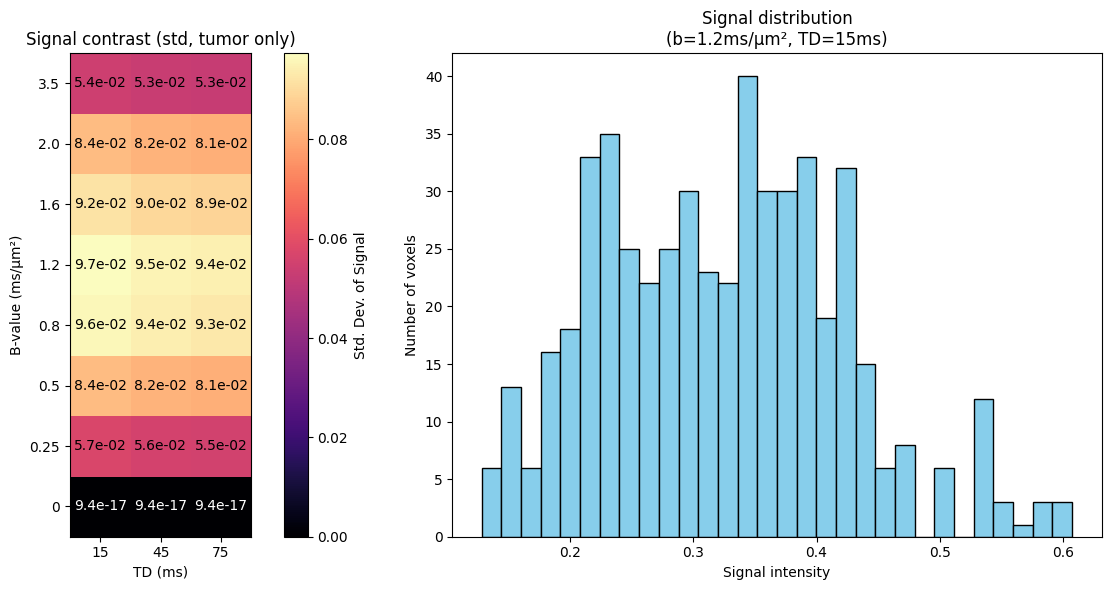

In [12]:
def plot_parameter_contrast_heatmap_tumor_only(AMBER_map, delta=4, bvecs=("0", "1", "2", "3", "4", "5"),
                                                hist_bval=0.5, hist_TD=45):
    N = AMBER_map.shape[0]
    contrast_matrix = np.zeros((len(bval_options), len(TD_options)))
    tri = Delaunay(params)

    # Store signal values at the selected (bval, TD) for histogram
    selected_signal_values = []

    for i_bval, bval in enumerate(bval_options):
        for i_TD, TD in enumerate(TD_options):
            signal_values_in_tumor = []

            for i in range(N):
                for j in range(N):
                    for k in range(N):
                        f = AMBER_map[i, j, k]["f"]
                        if f >= 0.007:  # Only tumor voxels
                            Dex = AMBER_map[i, j, k]["Dex"]
                            rmean = AMBER_map[i, j, k]["rmean"]
                            rsd = AMBER_map[i, j, k]["rsd"]
                            signal = interpolate_signal(f, Dex, rmean, rsd, bval, TD, delta, bvecs, tri)
                            signal_values_in_tumor.append(signal)

                            # Save for histogram if matches requested (bval, TD)
                            if bval == hist_bval and TD == hist_TD:
                                selected_signal_values.append(signal)

            # Fill the contrast matrix
            if signal_values_in_tumor:
                contrast_matrix[i_bval, i_TD] = np.std(signal_values_in_tumor)
            else:
                contrast_matrix[i_bval, i_TD] = 0  # Security

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Heatmap
    im = axs[0].imshow(contrast_matrix, cmap='magma', origin='lower')
    axs[0].set_xticks(np.arange(len(TD_options)))
    axs[0].set_xticklabels(TD_options)
    axs[0].set_yticks(np.arange(len(bval_options)))
    axs[0].set_yticklabels(bval_options)
    axs[0].set_xlabel("TD (ms)")
    axs[0].set_ylabel("B-value (ms/μm²)")
    axs[0].set_title("Signal contrast (std, tumor only)")
    plt.colorbar(im, ax=axs[0], label="Std. Dev. of Signal")

    # Add text annotations
    for i in range(len(bval_options)):
        for j in range(len(TD_options)):
            value = contrast_matrix[i, j]
            axs[0].text(j, i, f"{value:.1e}", ha='center', va='center', color='white' if value < 0.5 * np.max(contrast_matrix) else 'black')
    
    # Histogram
    if selected_signal_values:
        axs[1].hist(selected_signal_values, bins=30, color='skyblue', edgecolor='black')
        axs[1].set_xlabel("Signal intensity")
        axs[1].set_ylabel("Number of voxels")
        axs[1].set_title(f"Signal distribution\n(b={hist_bval}ms/μm², TD={hist_TD}ms)")
    else:
        axs[1].text(0.5, 0.5, "No tumor signal values found", ha='center', va='center')
        axs[1].set_axis_off()

    plt.tight_layout()
    if not os.path.exists('Figures'):
            os.mkdir('Figures')
        
    fig.savefig('Figures/Heatmap_high_high_dif.png', dpi=300, bbox_inches='tight')  # dpi=300 pour haute qualité
    plt.show()

plot_parameter_contrast_heatmap_tumor_only(AMBER_map_high_high_dif, 4, ("0","1","2","3","4","5"), 1.2, 15)